In [314]:
import pandas as pd

In [315]:
df = pd.read_csv("/Users/massinissat/Documents/optiLevel/Learning/MLOps/zoomcamp/mlbookcamp-code/chapter-02-car-price/data.csv")

In [316]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [317]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [318]:
strings = list(df.dtypes[df.dtypes == "str"].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [319]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [320]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [321]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [322]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

<Axes: xlabel='msrp', ylabel='Count'>

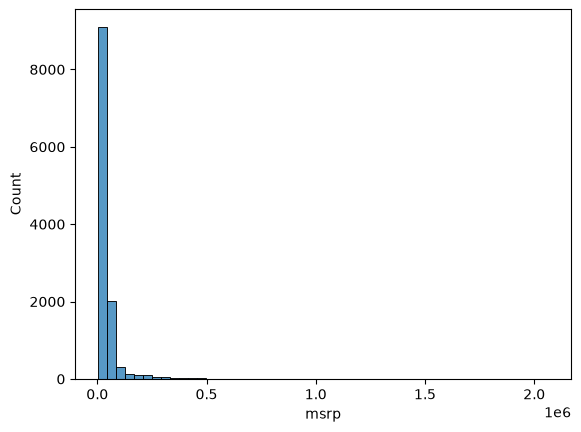

In [323]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

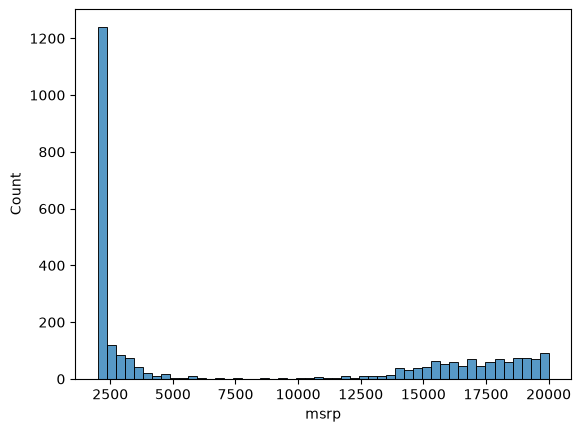

In [324]:
sns.histplot(df.msrp[df.msrp < 20_000], bins=50)

In [325]:
price_log = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

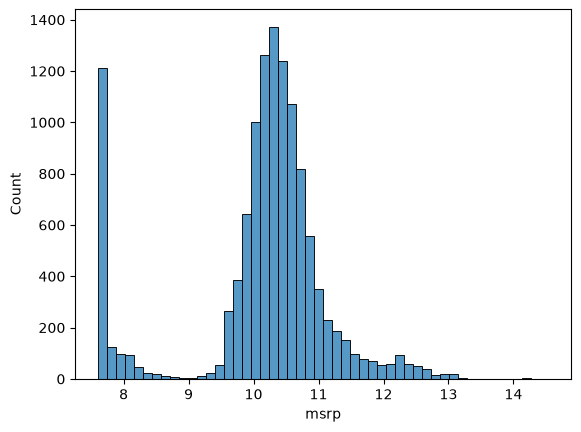

In [326]:
sns.histplot(price_log, bins=50)

In [327]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [328]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n_train, n_val, n_test

(7150, 2382, 2382)

In [329]:
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

df_val = df.iloc[idx[:n_val]]
df_test = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]

len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [330]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [331]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [332]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [333]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [334]:
def linear_regression(xi, w0, w):
   n = len(xi)
   pred = w0

   for j in range(n):
      pred = pred + w[j] * xi[j]

   return pred

In [335]:
lr = linear_regression(xi, w0, w)
np.expm1(lr)

np.float64(222347.2221101062)

In [336]:
def dot(xi, w):
    n = len(xi)
    result = 0

    for j in range(n):
        result += xi[j] * w[j]

    return result

def linear_regression(xi, w):
    xi = [1] + xi
    return dot(xi, w)

In [337]:
w = [w0] + w
linear_regression(xi, w)

12.312

In [338]:
def linear_regression(X, w):
    return X.dot(w)

In [339]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

In [340]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)

y = [100, 200, 150, 250, 100, 200, 150, 250, 120]
w_full = XTX_inv.dot(X.T).dot(y)

In [341]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([ 3.00067767e+02, -2.27742529e-01, -2.57694130e+00, -2.30120640e-02])

In [342]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


In [343]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [344]:
df_train.head()
base = df_train.columns[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')]
base  

Index(['year', 'engine_hp', 'engine_cylinders', 'number_of_doors',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [345]:
X_train = df_train[base].values
df_train[base].isnull().sum()

year                 0
engine_hp           43
engine_cylinders    20
number_of_doors      3
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [346]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
w0, w
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.42293691, 10.3166396 , 10.15781446, ...,  9.67941313,
       10.27472576, 10.63987072], shape=(7150,))

<Axes: ylabel='Count'>

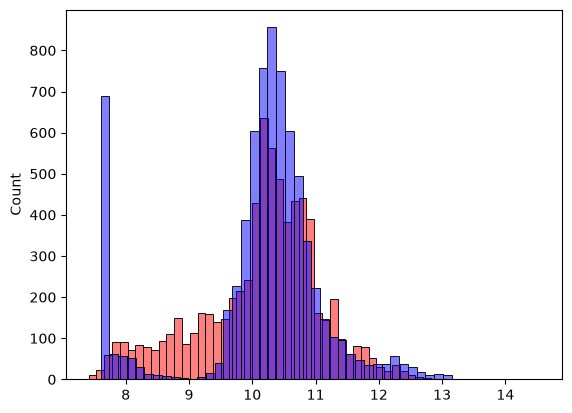

In [347]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [348]:
def root_mean_squared_error(y_true, y_pred):
    error = y_true - y_pred
    se = error ** 2
    mse = se.mean()
    return mse ** 0.5


In [349]:
root_mean_squared_error(y_train, y_pred)

np.float64(0.5134876533319498)

In [350]:
def prepare_X(df, base):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [351]:
X_val = prepare_X(df_val, base)
y_pred = w0 + X_val.dot(w)
rmse = root_mean_squared_error(y_val, y_pred)
print(rmse)

0.522297062176568


In [352]:
def prepare_X_v1(df, base):
    df = df.copy()
    
    df['age'] = 2026 - df.year
    features = np.append(base, 'age')

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [353]:
base = base[base != 'year']
df.number_of_doors.value_counts()

number_of_doors
4.0    8353
2.0    3160
3.0     395
Name: count, dtype: int64

In [354]:
X_train = prepare_X_v1(df_train, base)
X_val = prepare_X_v1(df_val, base)

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_val.dot(w)
rmse = root_mean_squared_error(y_val, y_pred)
print(rmse)


0.5222970621781018


In [355]:
base = base[base != 'number_of_doors']
base

Index(['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg',
       'popularity'],
      dtype='str')

In [356]:
def prepare_X_v2(df, base):
    df = df.copy()
    
    df['age'] = 2026 - df.year
    features = np.append(base, 'age')

    for v in [2, 3, 4]:
        df[f'number_of_doors_{v}'] = (df.number_of_doors == v).astype(int)
        features = np.append(features, f'number_of_doors_{v}')
        
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [358]:
X_train = prepare_X_v2(df_train, base)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_v2(df_val, base)

y_pred = w0 + X_val.dot(w)
root_mean_squared_error(y_val, y_pred)

np.float64(0.5210137656824522)

In [ ]:
makes = list(df.make.value_counts().head().index)
 

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [369]:
def prepare_X_v3(df, base, categories):
    df = df.copy()
    
    df['age'] = 2026 - df.year
    features = np.append(base, 'age')

    for v in [2, 3, 4]:
        df[f'number_of_doors_{v}'] = (df.number_of_doors == v).astype(int)
        features = np.append(features, f'number_of_doors_{v}')

    for v in makes:
        df[f'make_{v}'] = (df.make == v).astype(int)
        features = np.append(features, f'make_{v}')
        
    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features = np.append(features, '%s_%s' % (c, v))
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [372]:
X_train = prepare_X_v3(df_train, base, categories)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_v3(df_val, base, categories)

y_pred = w0 + X_val.dot(w)
root_mean_squared_error(y_val, y_pred)

np.float64(12750.07462325488)

# 13 Regulation

In [373]:
def train_linear_regression(X, y, r = 0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]


In [380]:
X_train = prepare_X_v3(df_train, base, categories)
w0, w = train_linear_regression(X_train, y_train, r = 0.01)

X_val = prepare_X_v3(df_val, base, categories)

y_pred = w0 + X_val.dot(w)
root_mean_squared_error(y_val, y_pred)

np.float64(0.4687150966815627)

# 14. Tuning the Model

In [383]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X_v3(df_train, base, categories)
    w0, w = train_linear_regression(X_train, y_train, r=r)

    X_val = prepare_X_v3(df_val, base, categories)
    y_pred = w0 + X_val.dot(w)
    score = root_mean_squared_error(y_val, y_pred)

    print(r, w0, score)

0.0 -2.526356365406326e+16 12750.07462325488
1e-05 11.106791744771499 0.4687170572457533
0.0001 6.8569265344015005 0.4687170440864798
0.001 6.793917092252727 0.4687168039358872
0.1 6.625962665857752 0.46875404335442106
1 5.874143631958766 0.4703057723586562
10 4.510115692896268 0.4839944993308165


# 15. Using the Model

In [384]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train = prepare_X_v3(df_full_train, base, categories)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression(X_full_train, y_full_train, r=0.001)

X_test = prepare_X_v3(df_test, base, categories)
y_pred = w0 + X_test.dot(w)
root_mean_squared_error(y_test, y_pred)

np.float64(0.4642459478039893)